In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [41]:
from pathlib import Path

BASE_DIR = Path("..")

users = pd.read_csv(BASE_DIR / "data/users.csv")

products = pd.read_csv(BASE_DIR / "data/products.csv")

categories = pd.read_csv(BASE_DIR / "data/categories.csv")

orders = pd.read_csv(BASE_DIR / "data/orders.csv")

order_items = pd.read_csv(BASE_DIR / "data/order_items.csv")

sessions = pd.read_csv(BASE_DIR / "data/sessions.csv")

In [42]:
users.head()
orders.head()
products.head()

,id,name,category_id,brand,price
0,1,Товар 1,2,Huawei,171218
1,2,Товар 2,10,Apple,16258
2,3,Товар 3,6,Huawei,36010
3,4,Товар 4,10,Huawei,20985
4,5,Товар 5,9,Huawei,156716


In [43]:
orders.head()

,id,user_id,order_date,status,payment_method,total_amount
0,1,201,2024-11-23 09:26:37.887090,delivered,card,102572
1,2,584,2025-02-01 00:34:39.448873,paid,sbp,147347
2,3,671,2024-08-08 15:51:40.195706,cancelled,sbp,70456
3,4,782,2026-03-06 12:40:25.208167,delivered,credit,171216
4,5,758,2026-05-24 09:22:59.481951,delivered,sbp,47101


In [44]:
products.head()

,id,name,category_id,brand,price
0,1,Товар 1,2,Huawei,171218
1,2,Товар 2,10,Apple,16258
2,3,Товар 3,6,Huawei,36010
3,4,Товар 4,10,Huawei,20985
4,5,Товар 5,9,Huawei,156716


In [45]:
print(users.shape)

(1000, 8)


In [46]:
print(products.shape)


(500, 5)


In [47]:
print(orders.shape)

(8000, 6)


In [48]:
print(order_items.shape)

(24132, 5)


In [49]:

print(sessions.shape)

(30000, 6)


In [50]:
users.isna().sum()

id                   0
first_name           0
last_name            0
email                0
gender               0
birth_date           0
city                 0
registration_date    0
dtype: int64

In [51]:
orders.isna().sum()

id                0
user_id           0
order_date        0
status            0
payment_method    0
total_amount      0
dtype: int64

In [52]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 1000 non-null   int64 
 1   first_name         1000 non-null   object
 2   last_name          1000 non-null   object
 3   email              1000 non-null   object
 4   gender             1000 non-null   object
 5   birth_date         1000 non-null   object
 6   city               1000 non-null   object
 7   registration_date  1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 62.6+ KB


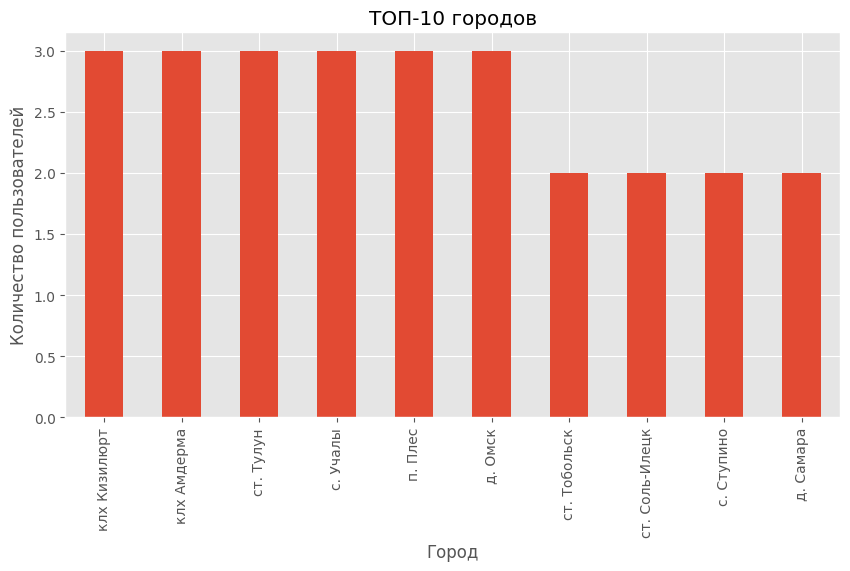

In [53]:
users["city"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("ТОП-10 городов")

plt.xlabel("Город")

plt.ylabel("Количество пользователей")

plt.show()

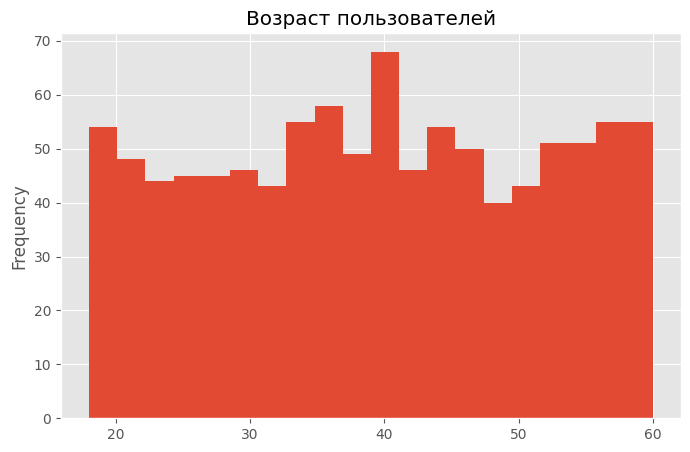

In [54]:
users["birth_date"] = pd.to_datetime(users["birth_date"])

users["age"] = (
    pd.Timestamp.today().year -
    users["birth_date"].dt.year
)

users["age"].plot(
    kind="hist",
    bins=20,
    figsize=(8,5)
)

plt.title("Возраст пользователей")

plt.show()

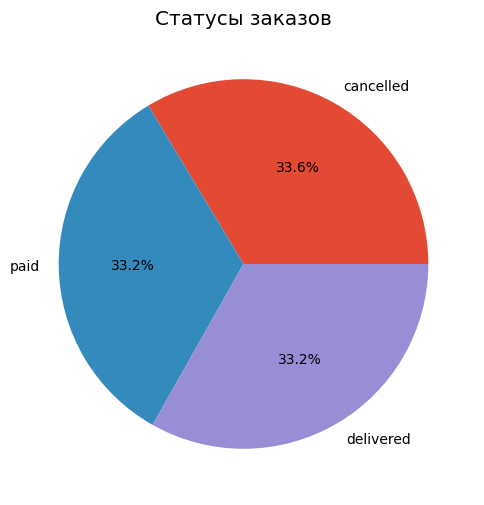

In [55]:
orders["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Статусы заказов")

plt.show()

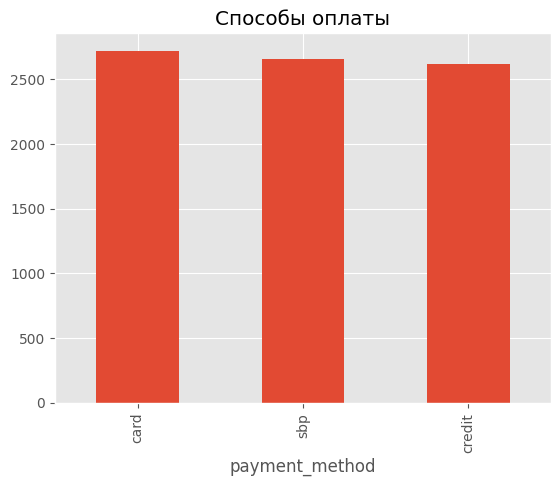

In [56]:
orders["payment_method"].value_counts().plot(
    kind="bar"
)

plt.title("Способы оплаты")

plt.show()

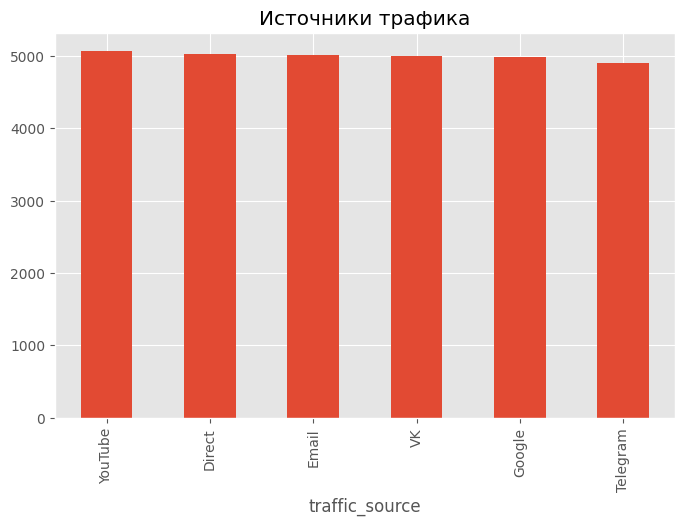

In [57]:
sessions["traffic_source"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Источники трафика")

plt.show()

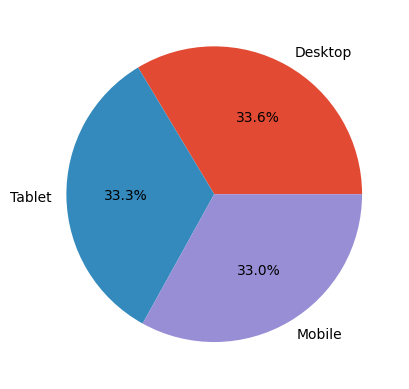

In [58]:
sessions["device"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

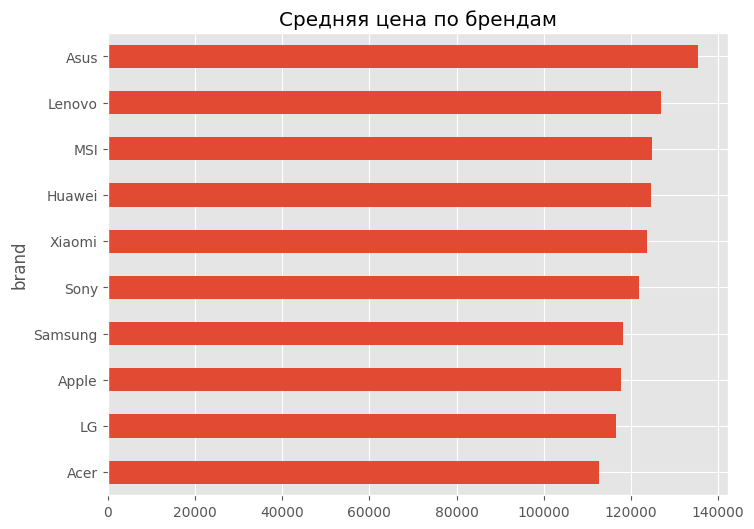

In [59]:
products.groupby("brand")["price"].mean().sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Средняя цена по брендам")

plt.show()

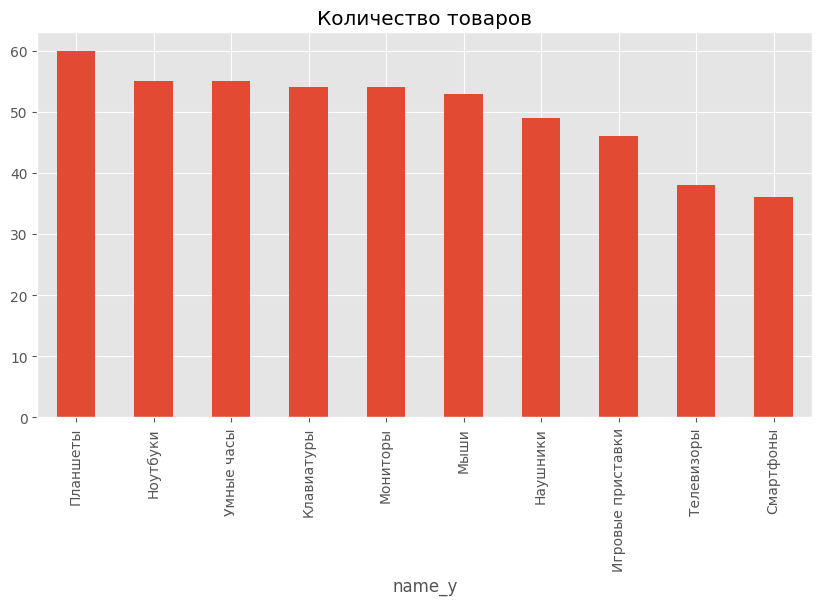

In [60]:
products = products.merge(
    categories,
    left_on="category_id",
    right_on="id"
)

products["name_y"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Количество товаров")

plt.show()

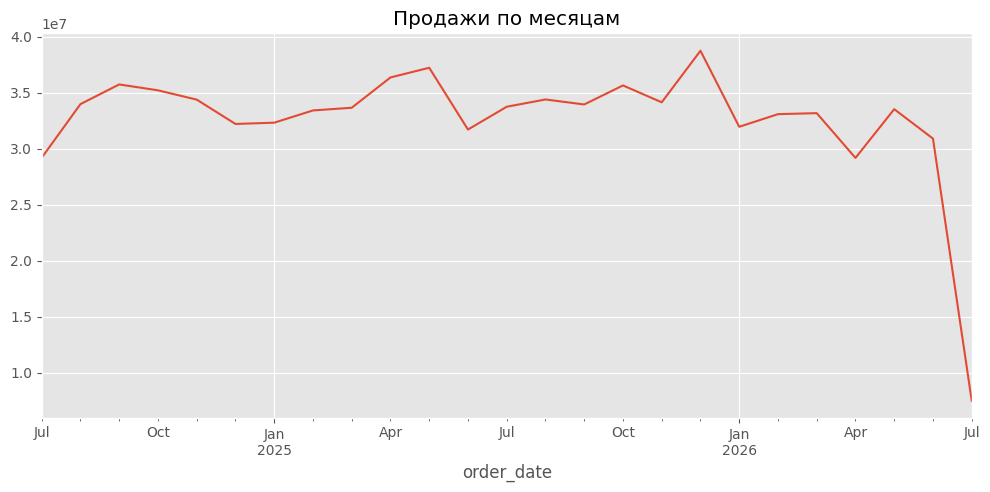

In [61]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

monthly = (
    orders
    .groupby(
        orders["order_date"].dt.to_period("M")
    )["total_amount"]
    .sum()
)

monthly.plot(
    figsize=(12,5)
)

plt.title("Продажи по месяцам")

plt.show()

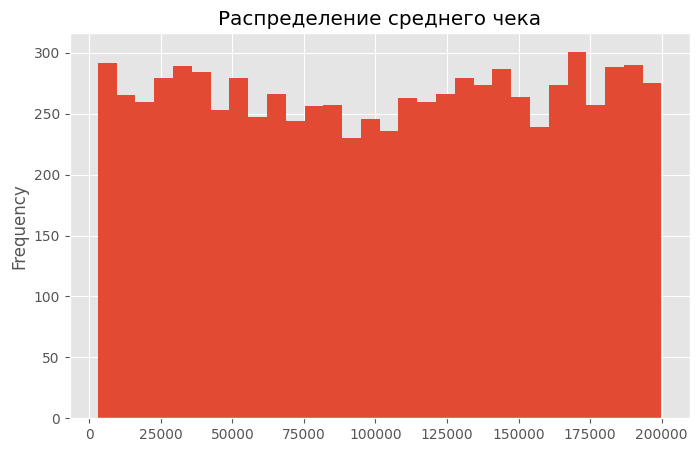

In [62]:
orders["total_amount"].plot(
    kind="hist",
    bins=30,
    figsize=(8,5)
)

plt.title("Распределение среднего чека")

plt.show()

# Анализ товаров

In [63]:
products["brand"].value_counts()

brand
Asus       60
Lenovo     55
Sony       53
LG         52
Apple      50
Acer       50
Samsung    48
Huawei     47
MSI        47
Xiaomi     38
Name: count, dtype: int64

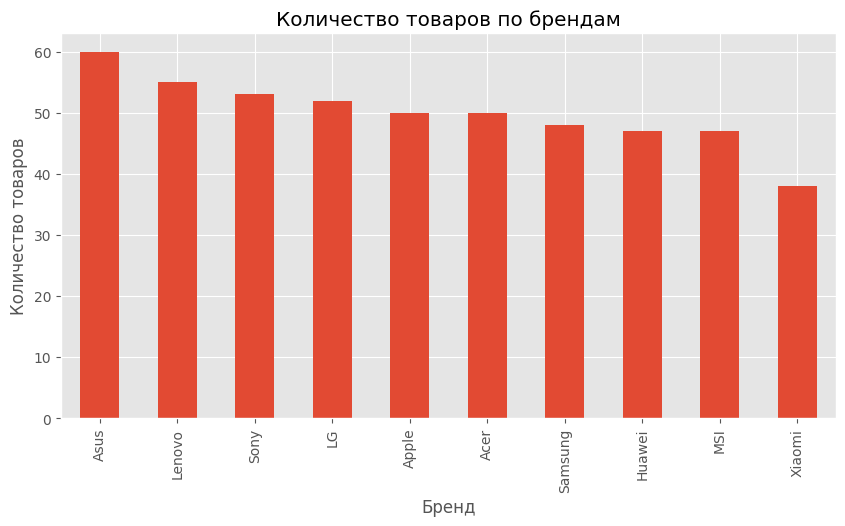

In [64]:
products["brand"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Количество товаров по брендам")
plt.xlabel("Бренд")
plt.ylabel("Количество товаров")

plt.show()

In [65]:
products.groupby("brand")["price"].mean().sort_values(ascending=False)

brand
Asus       135410.916667
Lenovo     126841.454545
MSI        124889.042553
Huawei     124687.234043
Xiaomi     123702.789474
Sony       121913.018868
Samsung    118180.500000
Apple      117759.000000
LG         116531.634615
Acer       112780.000000
Name: price, dtype: float64

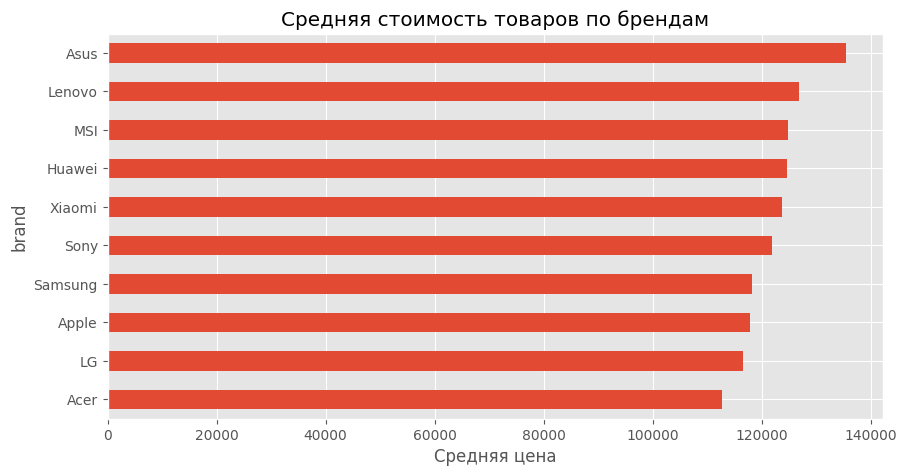

In [66]:
products.groupby("brand")["price"].mean().sort_values().plot(
    kind="barh",
    figsize=(10, 5)
)

plt.title("Средняя стоимость товаров по брендам")
plt.xlabel("Средняя цена")

plt.show()  

In [67]:
products = products.merge(
    categories,
    left_on="category_id",
    right_on="id",
    suffixes=("", "_category")
)

products.head()

,id_x,name_x,category_id,brand,price,id_y,name_y,id,name
0,1,Товар 1,2,Huawei,171218,2,Ноутбуки,2,Ноутбуки
1,2,Товар 2,10,Apple,16258,10,Мыши,10,Мыши
2,3,Товар 3,6,Huawei,36010,6,Умные часы,6,Умные часы
3,4,Товар 4,10,Huawei,20985,10,Мыши,10,Мыши
4,5,Товар 5,9,Huawei,156716,9,Клавиатуры,9,Клавиатуры


In [69]:
products["name_category"].value_counts()

KeyError: 'name_category'

In [ ]:
products["name_category"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Количество товаров по категориям")
plt.xlabel("Категория")
plt.ylabel("Количество товаров")

plt.xticks(rotation=45)

plt.show()